In [15]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
df['Age'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['HasCabin'] = df['Cabin'].notnull().astype(int)
df = df.drop('Cabin', axis=1)

df = df.drop(['PassengerId', 'Ticket'], axis=1)

df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
HasCabin,0


In [17]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

df = df.drop('Name', axis=1)

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_11788/3046491001.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,1,0,7.2500,0,False,True,False,True,False,False
1,1,1,1,38.0,1,0,71.2833,1,False,False,False,False,True,False
2,1,3,1,26.0,0,0,7.9250,0,False,True,True,False,False,False
3,1,1,1,35.0,1,0,53.1000,1,False,True,False,False,True,False
4,0,3,0,35.0,0,0,8.0500,0,False,True,False,True,False,False


In [18]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(712, 13) (179, 13)


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("All 3 models trained")

All 3 models trained


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_pred = log_reg.predict(X_test_scaled)
rf_pred = rf.predict(X_test)
knn_pred = knn.predict(X_test_scaled)

models = ['Logistic Regression', 'Random Forest', 'KNN']
predictions = [log_pred, rf_pred, knn_pred]

results = []
for name, pred in zip(models, predictions):
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.832402   0.797297  0.797297  0.797297
1        Random Forest  0.832402   0.797297  0.797297  0.797297
2                  KNN  0.798883   0.756757  0.756757  0.756757


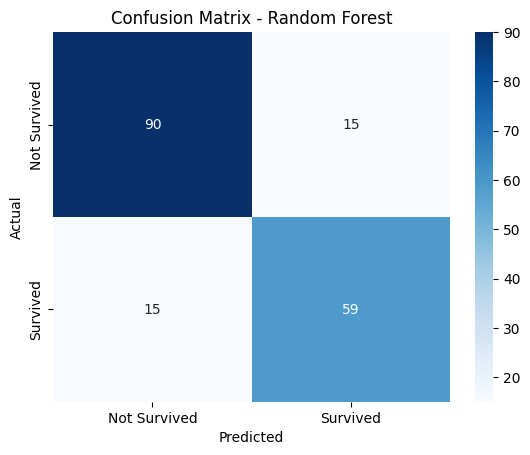

Fare          0.232553
Age           0.218806
Title_Mr      0.130342
Sex           0.112235
Pclass        0.071826
SibSp         0.052543
HasCabin      0.040023
Title_Mrs     0.037712
Parch         0.033870
Title_Miss    0.028272
Embarked_S    0.022236
Embarked_Q    0.011313
Title_Rare    0.008269
dtype: float64


In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived','Survived'],
            yticklabels=['Not Survived','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

In [22]:
import numpy as np

new_passenger = pd.DataFrame({
    'Pclass': [1],
    'Sex': [1],        # 1 = female
    'Age': [29],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [100],
    'HasCabin': [1],
    'Embarked_Q': [False],
    'Embarked_S': [False],
    'Title_Miss': [0],
    'Title_Mr': [0],
    'Title_Mrs': [1],
    'Title_Rare': [0]
})

prediction = rf.predict(new_passenger)
print("Survived" if prediction[0] == 1 else "Did not survive")

Survived
